In [6]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from tqdm import tqdm

# Init data

shapeMatrix = pd.read_pickle("../data/resmat.pkl")
shapeMatrix.fillna(shapeMatrix.mean(), inplace=True)
normalized_shapeMatrix=(shapeMatrix-shapeMatrix.mean())/shapeMatrix.std()
pca = PCA(shapeMatrix.shape[0]-1)
pca.fit(normalized_shapeMatrix)

,n_components,182
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [7]:
import numpy as np

# Assuming 'pca' is your fitted PCA object
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
k_90_percent = np.argmax(cumulative_variance >= 0.90) + 1

print(f"Number of components to explain 90% variance: {k_90_percent}")

Number of components to explain 90% variance: 93


In [8]:
# pca.explained_variance_ contains the eigenvalues for each component
k_kaiser = np.sum(pca.explained_variance_ > 1)

print(f"Number of components suggested by Kaiser's Criterion: {k_kaiser}")

Number of components suggested by Kaiser's Criterion: 182


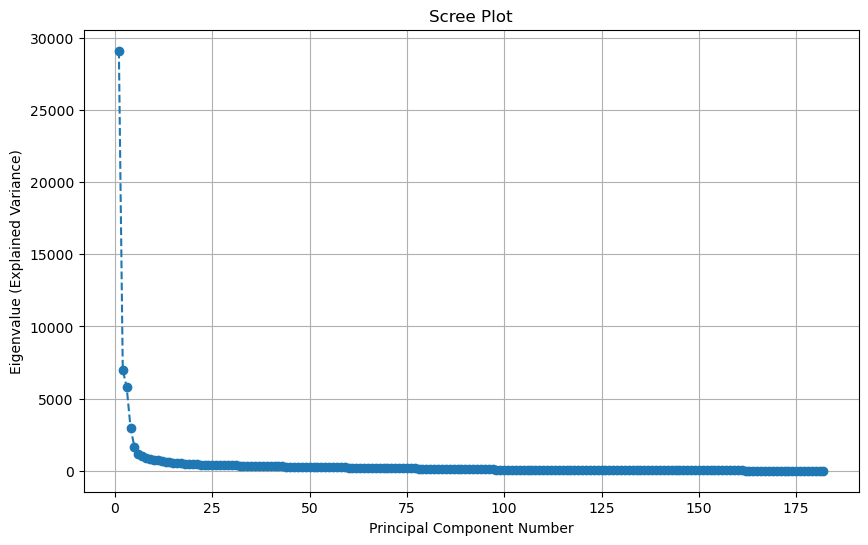

In [14]:
# Assuming you have already run your PCA as in the query
# pca = PCA(shapeMatrix.shape[0]-1)
# pca.fit(normalized_shapeMatrix)

# Get the eigenvalues (explained variance)
eigenvalues = pca.explained_variance_

# Create the scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Principal Component Number')
plt.ylabel('Eigenvalue (Explained Variance)')
plt.grid(True)
plt.show()


In [15]:
# Get the eigenvalues from your fitted PCA model
eigenvalues = pca.explained_variance_

# Filter for eigenvalues > 1
factors_kaiser = sum(eigenvalues > 1)

print(f"According to the Kaiser criterion, retain {factors_kaiser} factors.")


According to the Kaiser criterion, retain 182 factors.


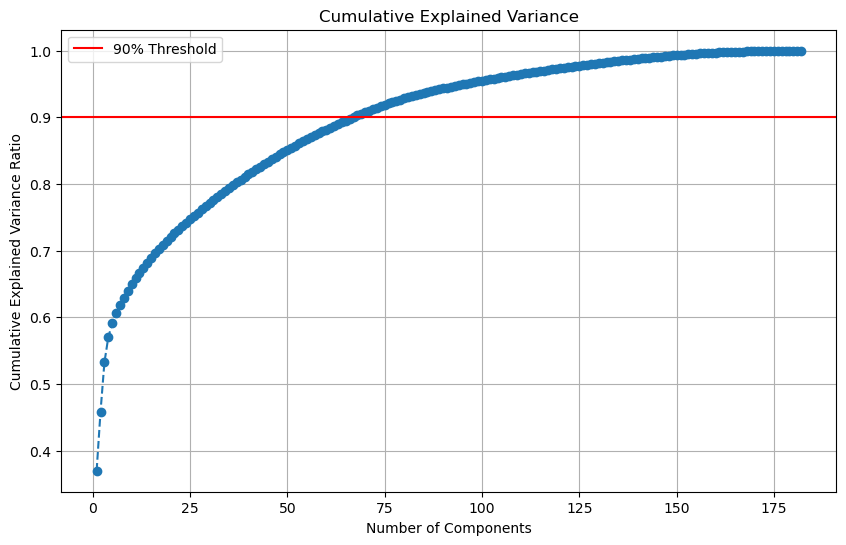

To explain at least 90.0% of the variance, you need 67 factors.


In [16]:
# Get the cumulative explained variance ratio
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot the cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.axhline(y=0.90, color='r', linestyle='-', label='90% Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Find the number of components for a given threshold
threshold = 0.90
num_factors_threshold = np.argmax(cumulative_variance >= threshold) + 1
print(f"To explain at least {threshold*100}% of the variance, you need {num_factors_threshold} factors.")


In [ ]:
k_factors = 5  # Example value based on one of the methods above
pca_final = PCA(n_components=k_factors)
transformed_data = pca_final.fit_transform(normalized_shapeMatrix)